In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor



In [2]:
end = dt.date.today()
start = dt.date.today() - dt.timedelta(days=365*5)
ticker = ['HDFCBANK.NS','^NSEI','^INDIAVIX','^NSEBANK']
df = yf.download(tickers=ticker,start=start,end=end,auto_adjust=True)['Close']

# Dropping Nans
df[df.isna().any(axis=1)]
df.dropna(inplace=True)

# Features Engineering
df['hdfc_returns'] = np.log(df['HDFCBANK.NS']/df['HDFCBANK.NS'].shift(1))
df['hdfc_lagged'] = df['hdfc_returns'].shift(1)
df['nse_returns'] = np.log(df['^NSEI']/df['^NSEI'].shift(1))
df['bank_returns'] = np.log(df['^NSEBANK']/df['^NSEBANK'].shift(1))
df['volatility'] = df['hdfc_returns'].rolling(20).std()
df['momentum'] = df['HDFCBANK.NS'].pct_change(5)

# Cleaning
df.drop(columns=['^NSEBANK','^NSEI','HDFCBANK.NS'],inplace=True)
df.dropna(inplace=True)
df.columns = df.columns.str.lower()
df.rename(columns = {'^indiavix':'vix'},inplace=True)
columns = ['hdfc_returns','hdfc_lagged','nse_returns','bank_returns','volatility','momentum','vix']
df = df[[col for col in columns if col in df.columns]]
train = int(len(df) * 0.8)
train_df = df.iloc[:train]
test_df = df.iloc[train:]

[*********************100%***********************]  4 of 4 completed


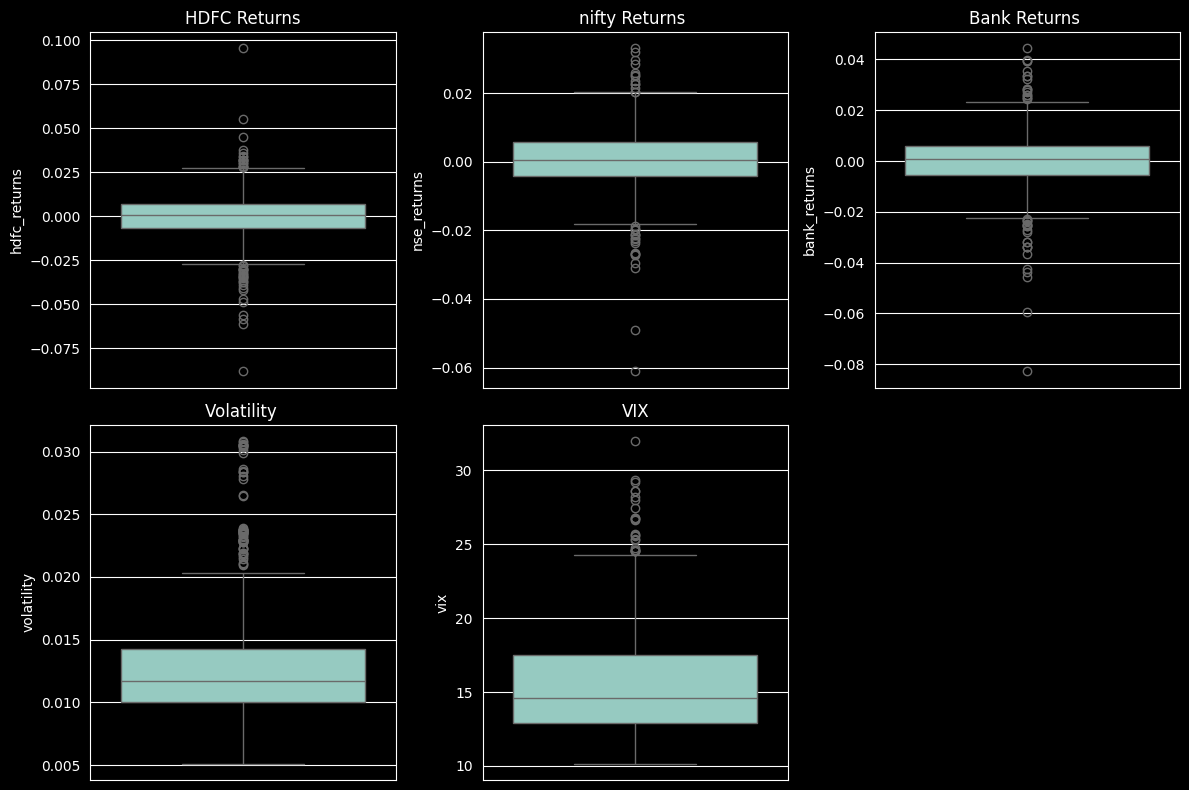

In [3]:
plt.figure(figsize = (12,8))

plt.subplot(2,3,1)
sns.boxplot(y = train_df['hdfc_returns'])
plt.title("HDFC Returns")

plt.subplot(2,3,2)
sns.boxplot(y = train_df['nse_returns'])
plt.title("nifty Returns ")

plt.subplot(2,3,3)
sns.boxplot(y = train_df['bank_returns'])
plt.title("Bank Returns ")

plt.subplot(2,3,4)
sns.boxplot(y = train_df['volatility'])
plt.title("Volatility ")

plt.subplot(2,3,5)
sns.boxplot(y = train_df['vix'])
plt.title("VIX")

plt.tight_layout()
plt.show()


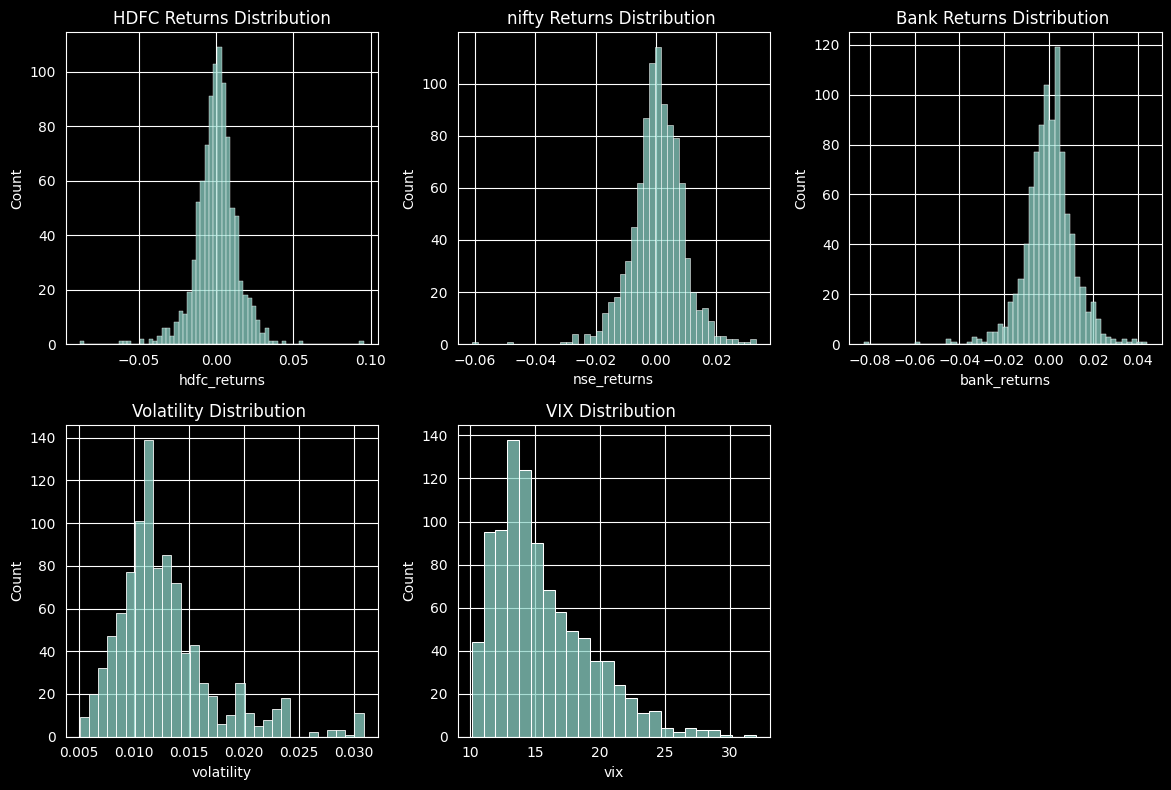

In [4]:
plt.figure(figsize = (12,8))

plt.subplot(2,3,1)
sns.histplot(train_df['hdfc_returns'])
plt.title("HDFC Returns Distribution")

plt.subplot(2,3,2)
sns.histplot(train_df['nse_returns'])
plt.title("nifty Returns Distribution ")

plt.subplot(2,3,3)
sns.histplot(train_df['bank_returns'])
plt.title("Bank Returns Distribution ")

plt.subplot(2,3,4)
sns.histplot(train_df['volatility'])
plt.title("Volatility Distribution ")

plt.subplot(2,3,5)
sns.histplot(train_df['vix'])
plt.title("VIX Distribution ")

plt.tight_layout()
plt.show()


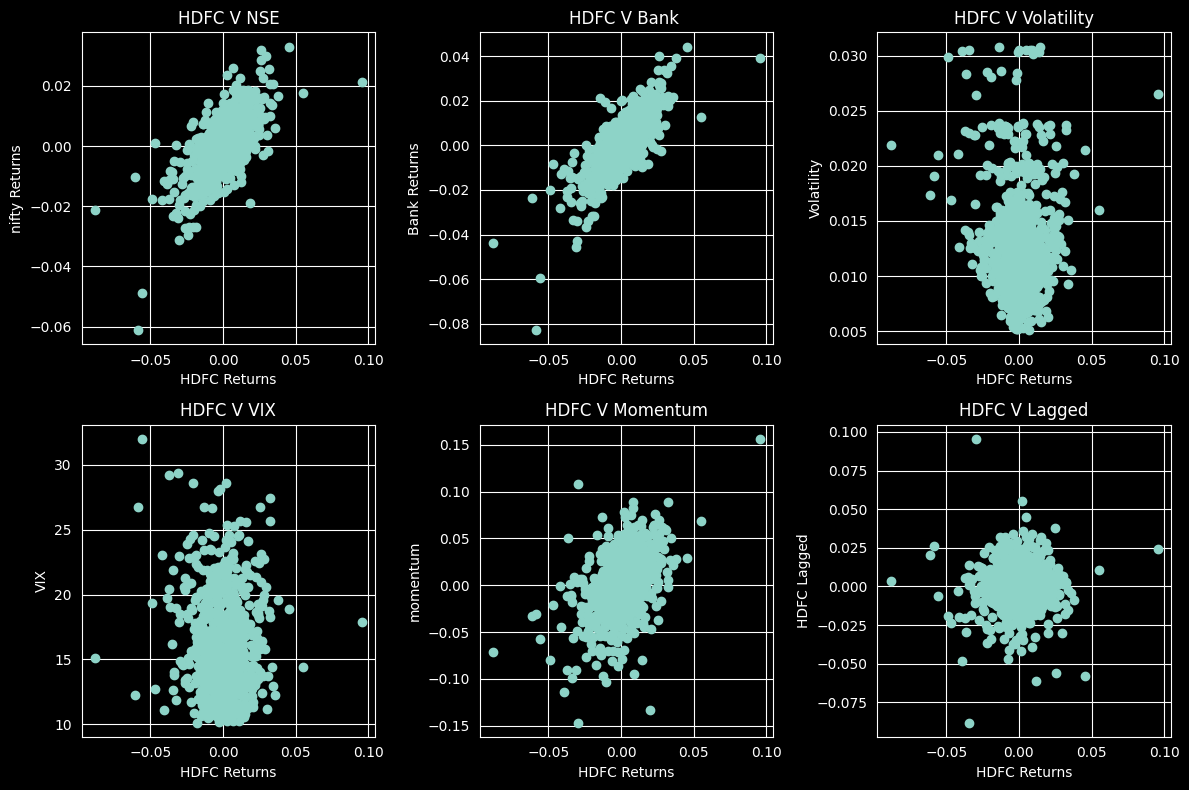

In [5]:
# Scatter Plot

plt.figure(figsize = (12,8))
plt.subplot(2,3,1)
plt.scatter(train_df['hdfc_returns'],train_df['nse_returns'])
plt.xlabel('HDFC Returns')
plt.ylabel('nifty Returns')
plt.title('HDFC V NSE')

plt.subplot(2,3,2)
plt.scatter(train_df['hdfc_returns'],train_df['bank_returns'])
plt.xlabel('HDFC Returns')
plt.ylabel('Bank Returns')
plt.title('HDFC V Bank ')

plt.subplot(2,3,3)
plt.scatter(train_df['hdfc_returns'],train_df['volatility'])
plt.xlabel('HDFC Returns')
plt.ylabel('Volatility')
plt.title('HDFC V Volatility')

plt.subplot(2,3,4)
plt.scatter(train_df['hdfc_returns'],train_df['vix'])
plt.xlabel('HDFC Returns')
plt.ylabel('VIX')
plt.title('HDFC V VIX')

plt.subplot(2,3,5)
plt.scatter(train_df['hdfc_returns'],train_df['momentum'])
plt.xlabel('HDFC Returns')
plt.ylabel('momentum')
plt.title('HDFC V Momentum')

plt.subplot(2,3,6)
plt.scatter(train_df['hdfc_returns'],train_df['hdfc_lagged'])
plt.xlabel('HDFC Returns')
plt.ylabel('HDFC Lagged')
plt.title('HDFC V Lagged')


plt.tight_layout()
plt.show()

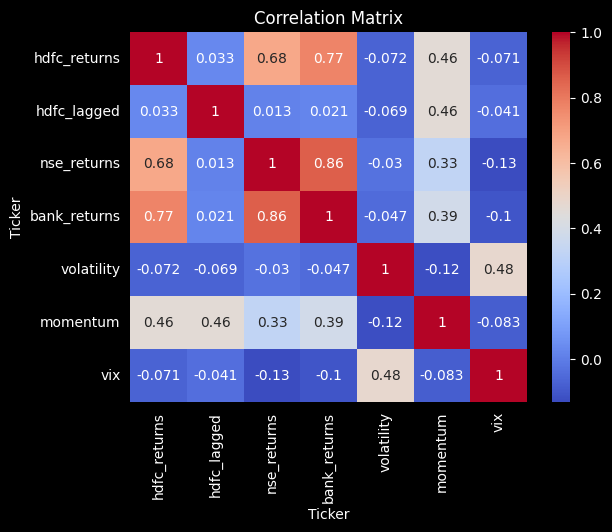

In [6]:
corr = train_df[['hdfc_returns','hdfc_lagged','nse_returns','bank_returns','volatility','momentum','vix']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [7]:
X = train_df[['hdfc_lagged','nse_returns','bank_returns','volatility','momentum']]
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

        Feature       VIF
0         const  9.274034
1   hdfc_lagged  1.315922
2   nse_returns  3.832761
3  bank_returns  4.061482
4    volatility  1.016358
5      momentum  1.558196


In [8]:
feature_logic = pd.DataFrame({
    "Feature": [
        "hdfc_lagged",
        "nse_return",
        "bank_return",
        "volatility",
        "momentum"
    ],
    "Reason": [
        "captures momentum or mean reversion",
        "market drives individual stocks",
        "banking sector drives HDFC",
        "higher risk reduces returns",
        "trend continuation"
    ],
    "Expected_Sign": [
        "±",   # could be positive or negative
        "+",
        "+",
        "-",
        "+"
    ],
    "Valid_Time": [
        True,  # uses past data
        True,
        True,
        True,
        True
    ]
})

print(feature_logic)

       Feature                               Reason Expected_Sign  Valid_Time
0  hdfc_lagged  captures momentum or mean reversion             ±        True
1   nse_return      market drives individual stocks             +        True
2  bank_return           banking sector drives HDFC             +        True
3   volatility          higher risk reduces returns             -        True
4     momentum                   trend continuation             +        True


In [9]:
# Check if any feature is using future data (simple check idea)

for col in ['hdfc_lagged', 'nse_returns', 'bank_returns', 'volatility', 'momentum']:
    if train_df[col].equals(df[col].shift(-1)):
        print(f"⚠️ {col} may contain future leakage")

In [10]:
corr_matrix = train_df[['hdfc_returns','hdfc_lagged','nse_returns','bank_returns','volatility','momentum']].corr()
print(corr_matrix['hdfc_returns'].sort_values(ascending=False))



Ticker
hdfc_returns    1.000000
bank_returns    0.773513
nse_returns     0.675802
momentum        0.459143
hdfc_lagged     0.032741
volatility     -0.071667
Name: hdfc_returns, dtype: float64


In [11]:
feature_corr = train_df[['nse_returns','bank_returns','volatility','momentum']].corr()
print(feature_corr)


Ticker        nse_returns  bank_returns  volatility  momentum
Ticker                                                       
nse_returns      1.000000      0.859632   -0.030333  0.326207
bank_returns     0.859632      1.000000   -0.047029  0.385091
volatility      -0.030333     -0.047029    1.000000 -0.124872
momentum         0.326207      0.385091   -0.124872  1.000000


In [12]:
train_df[['hdfc_returns','nse_returns','bank_returns']].describe()

# Keep only valid features
valid_features = feature_logic[
    (feature_logic["Valid_Time"] == True)
]["Feature"].tolist()

print("Final Features Used:", valid_features)

Final Features Used: ['hdfc_lagged', 'nse_return', 'bank_return', 'volatility', 'momentum']


In [13]:
train_df

Ticker,hdfc_returns,hdfc_lagged,nse_returns,bank_returns,volatility,momentum,vix
Date,,,,,,,
2021-04-29,-0.002916,0.026138,0.002040,-0.000246,0.021591,0.035149,23.309999
2021-04-30,-0.041742,-0.002916,-0.017870,-0.028055,0.021116,-0.001308,23.030001
2021-05-03,0.001521,-0.041742,0.000208,-0.009688,0.019503,0.006869,23.690001
2021-05-04,-0.018625,0.001521,-0.009451,-0.006037,0.019824,-0.034997,23.010000
2021-05-06,0.008999,-0.018625,0.015626,0.017127,0.019308,-0.051395,22.040001
...,...,...,...,...,...,...,...
2025-03-25,0.011846,0.016609,0.000435,-0.001878,0.010279,0.064926,13.640000
2025-03-26,-0.008214,0.011846,-0.007711,-0.007760,0.010220,0.035806,13.470000
2025-03-27,0.010353,-0.008214,0.004465,0.007138,0.010325,0.032000,13.300000


In [14]:
x = train_df[['bank_returns','hdfc_lagged','momentum']]
y = train_df['hdfc_returns']

x = sm.add_constant(x)
model = sm.OLS(y, x)
results = model.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:           hdfc_returns   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     555.3
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          6.09e-209
Time:                        16:48:31   Log-Likelihood:                 3261.5
No. Observations:                 961   AIC:                            -6515.
Df Residuals:                     957   BIC:                            -6495.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0003      0.000     -1.135   